In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Run this cell if you're using from colab
!git clone https://github.com/R-Oc-A/HackathonPastryLPV.git
!wget https://github.com/R-Oc-A/HackathonPastryLPV/releases/download/IntensityGrids/grids.tar.gz
!wget https://github.com/R-Oc-A/HackathonPastryLPV/releases/download/IntensityGrids/famias.tar.gz
!tar -xvf grids.tar.gz
!tar -xvf famias_grids.tar.gz
!pip install https://github.com/R-Oc-A/HackathonPastryLPV/releases/download/wheel/pastrypy-010-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl
!pip install -q tomli_w
!pip install -q healpy
!pip install -q huggingface_hub

In [12]:
try:
    import google.colab  # noqa: F401
except ImportError:
    is_colab=False
    import pyvista as pv
    from trame_pyvista.jupyter import launch_server
    await launch_server().ready
    import os
    GRIDS = "/home/ricardo/Software/Pulstar/pulstarRust/profile/grids"
else:
    is_colab =True
    import sys
    sys.path.append('/content/HackathonPastryLPV')
    import os
    os.environ["GRIDS"]="/content/ema_parquets/"
    !wget "https://fem-on-colab.github.io/releases/vtk-install.sh" -O "/tmp/vtk-install.sh" && bash "/tmp/vtk-install.sh"
    import pyvista as pv

In [1]:
import pastrypy as psp
import pulsation_description as plsd
import line_profile_description as lpd
import tomli_w
import polars as pl
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
#from huggingface_hub import hf_hub_download
from IPython.display import Image
import plot_polarsdf as plot_pl

# Grid Familiarization activity

### Regular Colatitude Azimuth (RCA) grid

In [3]:

nside=4
sphere = pv.Sphere(radius=1, phi_resolution=nside*2, theta_resolution=nside*4)
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(sphere, show_edges=True, color='white', opacity=1)

plotter.show(jupyter_backend="html", return_viewer=True)

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

### Healpix discretization
Hierarchical equal area pixelization of the surface

In [4]:
depth = 2
nside =np.pow(2,depth)
npix = hp.nside2npix(nside)
boundaries = hp.boundaries(nside, np.arange(npix),step=1)
print(f"the number of surface cells is {npix}")

the number of surface cells is 192


In [5]:
all_vertices = np.zeros((npix * 4,3))
faces =[]
for i in range(npix):
    # Extract the 4 corners for this pixel
    corners = boundaries[i,:, :].T
    
    all_vertices[i*4:(i+1)*4]=corners
    # Define the face: 4 vertices in the 
    # face
    base = i*4
    faces.append([4, base, base+1, base+2, base+3])

faces_flat = np.hstack(faces)
mesh = pv.PolyData(all_vertices, faces=faces_flat)
centers = mesh.cell_centers()
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(mesh, show_edges=True, color='white', edge_color='black', line_width=1)
plotter.add_mesh(centers,color = 'blue', point_size=3, render_points_as_spheres=True)
plotter.add_mesh(pv.Sphere(radius=0.99),color = 'white', opacity = 0.3)
plotter.show(jupyter_backend="html", return_viewer=True)


EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

Healpix enables easy manipulation of the surface

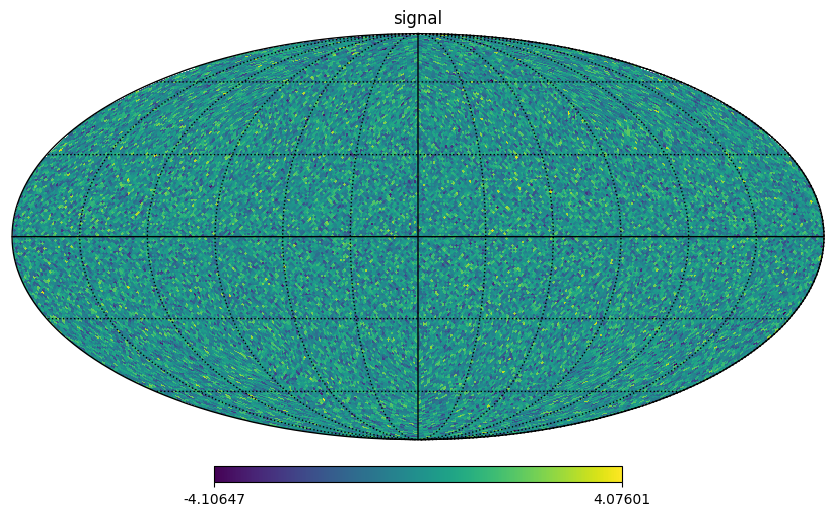

In [6]:
nside = 64
npix = hp.nside2npix(nside)
np.random.seed(12)
signal = np.random.normal(size=npix)
hp.mollview(signal,title="signal")
hp.graticule()

In [7]:
gal_cut = np.radians(10)
phase=+0.25
mask = np.zeros(npix,dtype = np.float32)
mask[hp.query_disc(nside,hp.ang2vec(np.pi/2,0+2*np.pi*phase),np.radians(30))] = 1
eclipse_mask = np.zeros(npix,dtype=np.float32)
apodized_mask = np.clip(hp.smoothing(mask,fwhm=np.radians(10)),0,None)
# hp.mollview(apodized_mask, cmap='plasma')
# hp.graticule()
# plt.savefig(fname="molview_left.png")

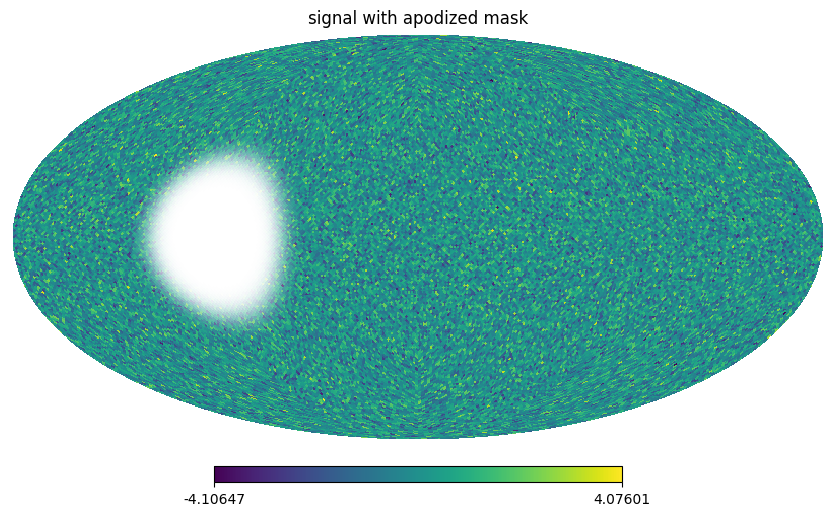

In [8]:
hp.mollview(signal,alpha=(1-apodized_mask),title="signal with apodized mask")

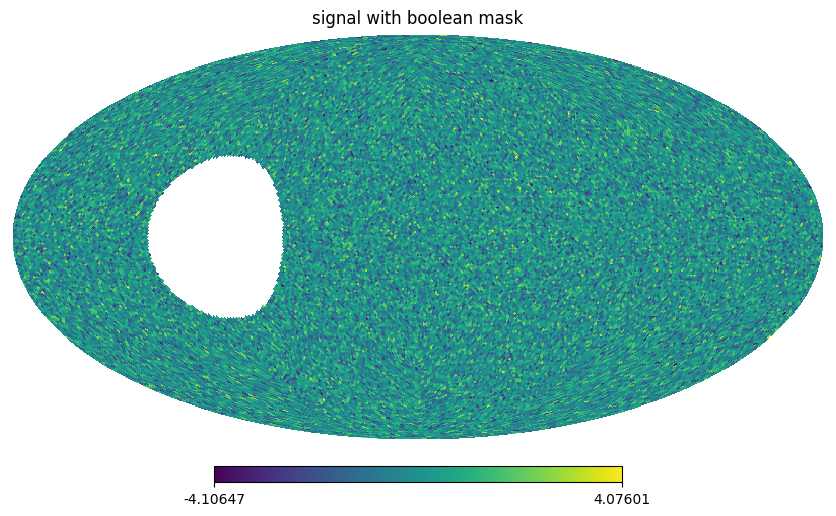

In [9]:
hp.mollview(signal,alpha=(1-mask),title="signal with boolean mask")

### Triangularization 
This is based on the marching step triangularization algorithm

In [11]:
sphere_points = psp.sphere_triangulation_points(length=0.2)
sphere_triangles = psp.sphere_triangulation_triangles(length=0.2)
sphere_triangles.head()
sphere_points.head()

I'm here, found some bad points, I guess.
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 4
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 3
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 2
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 1
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 0
----------------------------------------
---------Triangulation Finished---------
----------------------------------------
I'm here, found some bad points, I guess.
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 4
length of actual front polygon is 4
-------

point_id,x coordinate,y coordinate,z coordinate
u32,f64,f64,f64
0,-0.999201,0.0,-0.039968
1,-0.971959,0.0,-0.235151
2,-0.975878,-0.169842,-0.137172
3,-0.983716,-0.169842,0.058788
4,-0.987636,0.0,0.156768


In [12]:
points_extracted = sphere_points[['x coordinate','y coordinate','z coordinate']].to_numpy()
triangles_extracted = sphere_triangles[['first vertex','second vertex','third vertex']].to_numpy()
faces = np.hstack([np.full((triangles_extracted.shape[0],1),3),triangles_extracted])
mesh = pv.PolyData(points_extracted,faces)
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(mesh)
plotter.add_axes()
plotter.show(jupyter_backend="html", return_viewer=True)

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

For a flattened star

<>:16: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:16: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_194928/825954854.py:16: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax.plot(color==color,linewidth=2,label=f'$\omega/\omega_{r'crit'}$={omega*np.sqrt(27.0/8.0):.3f}')
/tmp/ipykernel_194928/825954854.py:27: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.grid(False, linestyle=':',alpha=0.6)


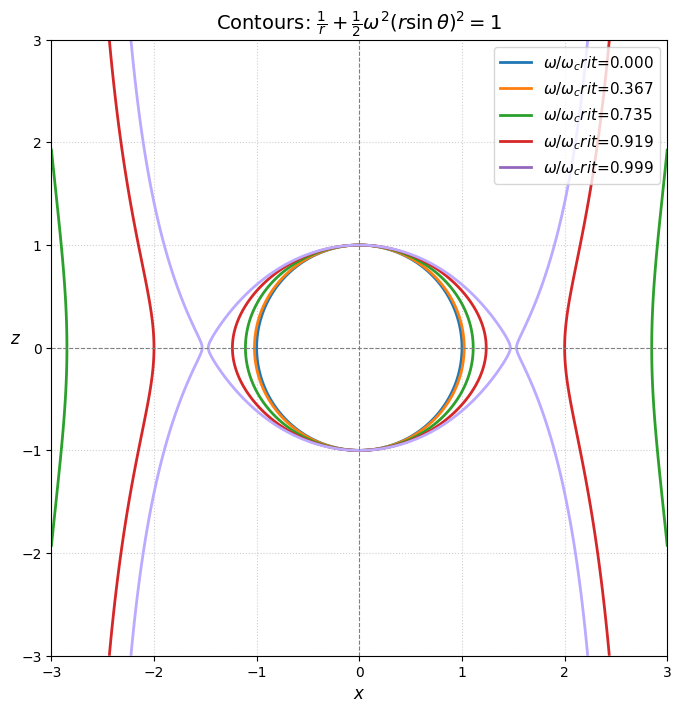

In [13]:
omegas = [0.0,0.2,0.4,0.5,0.544]
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#bbaaff']

x=np.linspace(-3,3,600)
y=np.linspace(-3,3,600)
X,Y=np.meshgrid(x,y)
R=np.sqrt(X**2 +Y**2)
R=np.where(R==0,1e-6,R)

fig, ax =plt.subplots(figsize=(8,8))

for index,omega in enumerate(omegas):
    color=colors[index]
    Z =1.0/R +0.5*(omega**2)*(X**2)-1.0
    ax.contour(X,Y,Z, levels=[0], colors=[color],linewidths=2)
    ax.plot(color==color,linewidth=2,label=f'$\omega/\omega_{r'crit'}$={omega*np.sqrt(27.0/8.0):.3f}')
    
ax.set_aspect('equal')
ax.axhline(0,color='gray',linewidth=0.8,linestyle='--')
ax.axvline(0,color='gray',linewidth=0.8,linestyle='--')
ax.set_title(
    r'Contours: $\frac{1}{r}+\frac{1}{2}\omega^2 (r\sin\theta )^2=1$',
    fontsize=14,
)
ax.set_xlabel('$x$',fontsize=12)
ax.set_ylabel('$z$',fontsize=12,rotation='horizontal')
ax.grid(False, linestyle=':',alpha=0.6)
ax.legend(loc='upper right',fontsize=11)
plt.xlim(-3,3)
plt.ylim(-3,3)
plt.show()

In [18]:
roche_points = psp.roche_deformed_triangulation_points(w=0.85,length=0.2)#w is the critical frequency, length is the length of each side of the triangle, approximately
roche_triangles = psp.roche_deformed_triangulation_triangles(w=0.85,length=0.2)

I'm here, found some bad points, I guess.
I'm here, found some bad points, I guess.
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 5
length of actual front polygon is 5
--------------------
I'm here, found some bad points, I guess.
I'm here, found some bad points, I guess.
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 4
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 3
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 2
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 1
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
putting last triangle
front 

In [19]:
points_extracted = roche_points[['x coordinate','y coordinate','z coordinate']].to_numpy()
triangles_extracted = roche_triangles[['first vertex','second vertex','third vertex']].to_numpy()
print(f"number of triangles is {triangles_extracted.size}")
faces = np.hstack([np.full((triangles_extracted.shape[0],1),3),triangles_extracted])
mesh = pv.PolyData(points_extracted,faces)
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(mesh)
plotter.add_axes()
plotter.show()#jupyter_backend="html", return_viewer=True)

number of triangles is 4014


Widget(value='<iframe src="http://localhost:44077/index.html?ui=P_0x70f644feefd0_5&reconnect=auto" class="pyvi…

# Pulstar 
Here you specify the star you'll be modelling as well as the modes of pulsation
### Star Data

In [2]:
star_data=plsd.StarData(mass=10.0,
                        radius=6.93,
                        effective_temperature=21642.0,
                        v_omega=20.0,
                        inclination_angle=45.0)

### Phases of pulsation to model (time in days)

In [3]:
time_points=plsd.TimePoints(Uniform=plsd.UniformTime(start=0.0,end=0.2,step=0.01))
#time_points=plsd.TimePoints(Uniform=plsd.ExplicitTime([0.0,0.01,0.4]))

### Pulsation modes to model

In [4]:
nonrot= plsd.NonRot()
pertcor=plsd.PerturbCor()
tar = plsd.TAR()
cendef = plsd.CenDef(coefficient_expansion=[-0.856,0.01,0.0])
rotation_regime = plsd.RotationRegime(NonRotating=None,PerturbativeCoriolis=None,Tar=None,CentrifugalDeformation=None)
rotation_regime.NonRotating=nonrot
#rotation_regime.PerturbativeCoriolis=pertcor
#rotation_regime.Tar=tar
#rotation_regime.CentrifugalDeformation=cendef

In [26]:
mode=plsd.Mode(l=2,m=1,
                rel_dr=0.024,
                k=0.03,frequency=5.38,
                phase_offset=0.0,
                rel_dtemp=0.0, #2.62,
                phase_rel_dtemp=0.0, #180.0,
                rel_dg=0.0, #10.0,
                phase_rel_dg=0.0, #34.0,
                rotation_effects = rotation_regime)

### Mesh options

In [27]:
#mesh=plsd.Mesh(Sphere=plsd.SphericalStar(theta_step=2.0,phi_step=4.0))
#mesh=plsd.Mesh(HSphere=plsd.HealpixStar(depth=5))
mesh = plsd.Mesh(TSphere=plsd.TriangulatedStar(triangle_length=0.1))
#mesh = plsd.Mesh(DSphere=plsd.DeformedStar(triangle_length=0.3,rotation_frequency=0.2))

### Putting it all together

In [28]:
pulsconfig=plsd.PulstarConfig(
    mode_data=[mode],
    star_data=star_data,
    time_points=time_points,
    mesh=mesh)

pulsconfig_dict=pulsconfig.model_dump(exclude_none=True)
puls_toml_string=tomli_w.dumps(pulsconfig_dict)
print(puls_toml_string)

[[mode_data]]
l = 2
m = 1
rel_dr = 0.024
k = 0.03
frequency = 5.38
phase_offset = 0.0
rel_dtemp = 0.0
phase_rel_dtemp = 0.0
rel_dg = 0.0
phase_rel_dg = 0.0

[mode_data.rotation_effects.NonRotating]

[star_data]
mass = 10.0
radius = 6.93
effective_temperature = 21642.0
v_omega = 20.0
inclination_angle = 45.0

[time_points.Uniform]
start = 0.0
end = 0.2
step = 0.01

[mesh.TSphere]
triangle_length = 0.1



## First run

In [29]:
pulse_df = psp.pulstar(puls_toml_string)
pulse_df.sort("time").head(5)

--------------------
--------------------
--------------------
|PULSTARust launched|
--------------------
I'm here, found some bad points, I guess.
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 8
length of actual front polygon is 6
--------------------
I'm here, found some bad points, I guess.
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 7
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 6
length of actual front polygon is 4
--------------------
putting last triangle
front polygons to be processed are 5
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
putting last triangle
front polygons to be processed are 4
length of actual front polygon is 4
--------------------
breaking while finishing points with small front angles
puttin

coord1,coord2,time,velocity,temperature,log gravity,coschi,area
f64,f64,f64,f64,f64,f64,f64,f64
1.674289,3.178855,0.0,-0.583341,21642.0,3.756534,0.778556,0.003334
1.610075,3.215716,0.0,-1.019987,21642.0,3.756534,0.745543,0.003198
1.546064,3.178576,0.0,-0.436646,21642.0,3.756534,0.71249,0.003061
1.546064,3.104582,0.0,0.436646,21642.0,3.756534,0.712512,0.003061
1.610075,3.067513,0.0,1.019987,21642.0,3.756534,0.745585,0.003198


In [30]:
pulse_df.describe()

statistic,coord1,coord2,time,velocity,temperature,log gravity,coschi,area
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",42533.0,42533.0,42533.0,42533.0,42533.0,42533.0,42533.0,42533.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2.03079,3.149097,0.099988,0.247969,21642.0,3.756534,0.486073,0.00155
"""std""",0.532121,1.412914,0.060557,14.257242,1.5175e-13,1.8524e-17,0.289515,0.00102
"""min""",0.781164,0.001953,0.0,-38.301674,21642.0,3.756534,0.000007,2.2970e-8
"""25%""",1.629744,2.066269,0.05,-10.296748,21642.0,3.756534,0.23158,0.000657
"""50%""",2.078652,3.148559,0.1,0.001187,21642.0,3.756534,0.478414,0.001428
"""75%""",2.444765,4.203178,0.15,10.619062,21642.0,3.756534,0.736686,0.002401
"""max""",3.129083,6.28185,0.2,38.425283,21642.0,3.756534,0.999947,0.004229


### Only available with triangulation mesh
#### Animate the pulsations 

In [31]:
#Define the names of the files 
point_parquet_names=[]
triangle_parquet_names=[]
#time_stamps = np.arange(0.01,0.10,0.01)
time_stamps = [f"{i/100:g}" for i in range(21)]
print(time_stamps)
for time in time_stamps:
    point_parquet_names.append(f"points{time}.parquet")
    triangle_parquet_names.append(f"triangles{time}.parquet")
    #point_parquet_names.append("points"+"{:.2f}".format(time)+".parquet")
    #triangle_parquet_names.append("triangles"+"{:.2f}".format(time)+".parquet")

print(point_parquet_names)
print(triangle_parquet_names)
plotter = pv.Plotter(notebook=False,off_screen=True)
points_df = pl.read_parquet(point_parquet_names[0])
triangles_df = pl.read_parquet(triangle_parquet_names[0])
points_extracted = (points_df[['x coordinate','y coordinate','z coordinate']].to_numpy())
triangles_extracted = triangles_df[['first vertex','second vertex','third vertex']].to_numpy()
faces = np.hstack([np.full((triangles_extracted.shape[0],1),3),triangles_extracted])
mesh = pv.PolyData(points_extracted,faces)
plotter.add_mesh(mesh,color='blue_violet',show_edges=True)

['0', '0.01', '0.02', '0.03', '0.04', '0.05', '0.06', '0.07', '0.08', '0.09', '0.1', '0.11', '0.12', '0.13', '0.14', '0.15', '0.16', '0.17', '0.18', '0.19', '0.2']
['points0.parquet', 'points0.01.parquet', 'points0.02.parquet', 'points0.03.parquet', 'points0.04.parquet', 'points0.05.parquet', 'points0.06.parquet', 'points0.07.parquet', 'points0.08.parquet', 'points0.09.parquet', 'points0.1.parquet', 'points0.11.parquet', 'points0.12.parquet', 'points0.13.parquet', 'points0.14.parquet', 'points0.15.parquet', 'points0.16.parquet', 'points0.17.parquet', 'points0.18.parquet', 'points0.19.parquet', 'points0.2.parquet']
['triangles0.parquet', 'triangles0.01.parquet', 'triangles0.02.parquet', 'triangles0.03.parquet', 'triangles0.04.parquet', 'triangles0.05.parquet', 'triangles0.06.parquet', 'triangles0.07.parquet', 'triangles0.08.parquet', 'triangles0.09.parquet', 'triangles0.1.parquet', 'triangles0.11.parquet', 'triangles0.12.parquet', 'triangles0.13.parquet', 'triangles0.14.parquet', 'trian

Actor (0x78fe9370f9a0)
  Center:                     (0.0001446083640167517, -2.819364798384294e-05, 1.978684682107934e-05)
  Pickable:                   True
  Position:                   (0.0, 0.0, 0.0)
  Scale:                      (1.0, 1.0, 1.0)
  Visible:                    True
  X Bounds                    -9.993E-01, 9.996E-01
  Y Bounds                    -9.995E-01, 9.994E-01
  Z Bounds                    -9.998E-01, 9.998E-01
  User matrix:                Identity
  Has mapper:                 True

Property (0x78fe3a374100)
  Ambient:                     0.0
  Ambient color:               Color(name='blue_violet', hex='#8a2be2ff', opacity=255)
  Anisotropy:                  0.0
  Anisotropy rotation:         0.0
  Color:                       Color(name='blue_violet', hex='#8a2be2ff', opacity=255)
  Culling:                     "none"
  Diffuse:                     1.0
  Diffuse color:               Color(name='blue_violet', hex='#8a2be2ff', opacity=255)
  Edge color:     

In [32]:
plotter.open_gif("pulsation_animation.gif")
for point_file in point_parquet_names:
    points_ddf = pl.read_parquet(point_file)
    pointss_extracted = (points_ddf[['x coordinate','y coordinate','z coordinate']].to_numpy())*1.0e0
    mesh.points=pointss_extracted
    plotter.write_frame()

plotter.close()
    

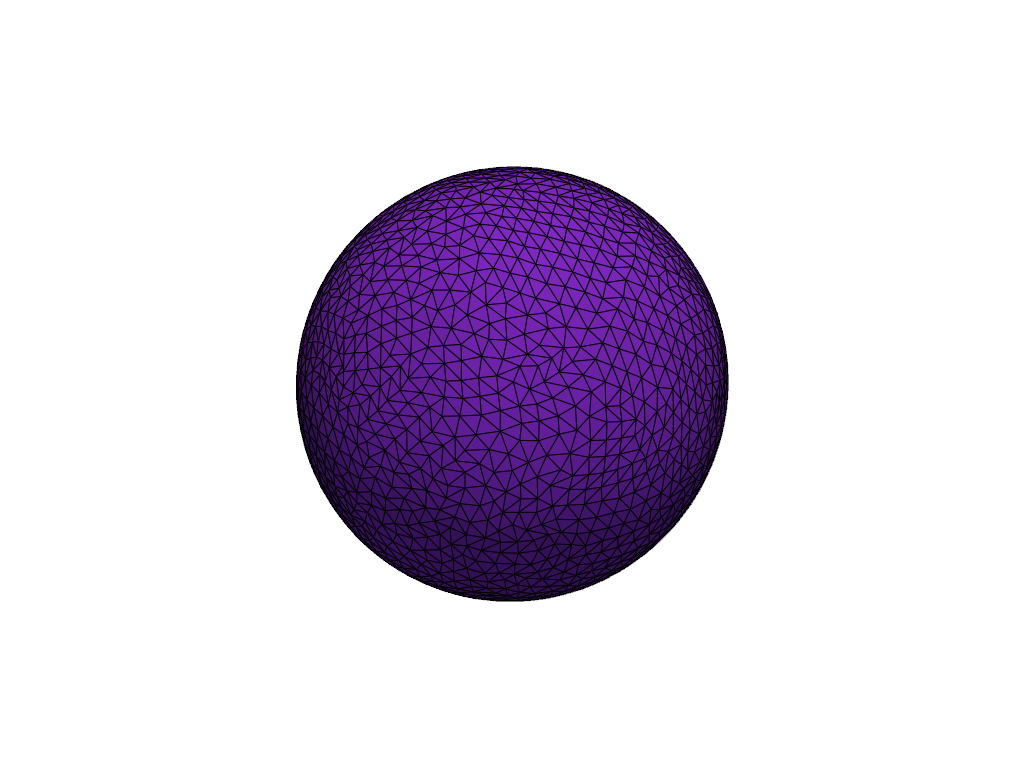

In [33]:
Image(filename="pulsation_animation.gif")

# Profile configuration
Here you specify the line profile variability you want to observe.

#### Select the chunk of the spectrum you want to model

In [ ]:
wl_range=lpd.WavelengthRange(Uniform=lpd.UniformWavelengthRange(start=4551.0,end=4555.0,step=0.033))

### FAMIAS approach
For this approach you select an absorption line from your observations and you model it as a Gaussian profile

In [34]:
gaussian_config = lpd.GaussianProfile(
    sigma=0.5,
    eq_w=0.5,
    alpha_w=0.0,
    zero_point_shift=0.0,
    # In Angstrom units
    central_wavelength=4553.0,
    wavelength_range=wl_range,
    t_eff=21000,
    mass = 10.0,
    radius = 6.93,
)

prof_config_dict=gaussian_config.model_dump(exclude_none=True)

prof_gauss_toml_string=tomli_w.dumps(prof_config_dict)
print(prof_gauss_toml_string)

sigma = 0.5
eq_w = 0.5
alpha_w = 0.0
zero_point_shift = 0.0
central_wavelength = 4553.0
t_eff = 21000.0
mass = 10.0
radius = 6.93

[wavelength_range.Uniform]
start = 4551.0
end = 4555.0
step = 0.0033



### Model atmosphere interpolation
Here we use a precomputed grid of model atmospheres to estimate local quantities out of the pulstar simulation

### Select the model atmospheres that you want to use

In [19]:
#print(os.environ)
path_to_grids = f"{GRIDS}/ema_parquets/"#f"{os.getenv("GRIDS")}"
print(path_to_grids)

grid1=lpd.IntensityGrid(EmaParquet=lpd.EmaGrid(temperature=20000.0,log_gravity=3.5,metalicity=0.0,filename="lp0000_20000_0350_0020.parquet"))
grid2=lpd.IntensityGrid(EmaParquet=lpd.EmaGrid(temperature=20000.0,log_gravity=3.9,metalicity=0.0,filename="lp0000_20000_0380_0020.parquet"))
grid3=lpd.IntensityGrid(EmaParquet=lpd.EmaGrid(temperature=24000.0,log_gravity=3.5,metalicity=0.0,filename="lp0000_24000_0350_0020.parquet"))
grid4=lpd.IntensityGrid(EmaParquet=lpd.EmaGrid(temperature=24000.0,log_gravity=3.9,metalicity=0.0,filename="lp0000_24000_0380_0020.parquet"))



/home/ricardo/Software/Pulstar/pulstarRust/profile/grids/ema_parquets/


#### putting it all together

In [35]:
prof_config=lpd.ProfileConfig(max_velocity=1.0e2,path_to_grids=path_to_grids,wavelength_range=wl_range,intensity_grids=[grid1,grid2,grid3,grid4])

prof_config_dict=prof_config.model_dump(exclude_none=True)

prof_toml_string=tomli_w.dumps(prof_config_dict)
print(prof_toml_string)


max_velocity = 100.0
path_to_grids = "/home/ricardo/Software/Pulstar/pulstarRust/profile/grids/ema_parquets/"

[wavelength_range.Uniform]
start = 4551.0
end = 4555.0
step = 0.0033

[[intensity_grids]]

[intensity_grids.EmaParquet]
temperature = 20000.0
log_gravity = 3.5
metalicity = 0.0
filename = "lp0000_20000_0350_0020.parquet"

[[intensity_grids]]

[intensity_grids.EmaParquet]
temperature = 20000.0
log_gravity = 3.9
metalicity = 0.0
filename = "lp0000_20000_0380_0020.parquet"

[[intensity_grids]]

[intensity_grids.EmaParquet]
temperature = 24000.0
log_gravity = 3.5
metalicity = 0.0
filename = "lp0000_24000_0350_0020.parquet"

[[intensity_grids]]

[intensity_grids.EmaParquet]
temperature = 24000.0
log_gravity = 3.9
metalicity = 0.0
filename = "lp0000_24000_0380_0020.parquet"



### First run

In [36]:
wavelength_gauss_df = psp.profile_gauss(prof_gauss_toml_string,pulse_df)
wavelength_gauss_df.head(5)

----------------------------------------
----------------------------------------
shape: (5, 8)
┌──────────┬──────────┬──────┬───────────┬─────────────┬─────────────┬──────────┬──────────┐
│ coord1   ┆ coord2   ┆ time ┆ velocity  ┆ temperature ┆ log gravity ┆ coschi   ┆ area     │
│ ---      ┆ ---      ┆ ---  ┆ ---       ┆ ---         ┆ ---         ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64  ┆ f64       ┆ f64         ┆ f64         ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════╪═══════════╪═════════════╪═════════════╪══════════╪══════════╡
│ 1.674289 ┆ 3.178855 ┆ 0.0  ┆ -0.583341 ┆ 21642.0     ┆ 3.756534    ┆ 0.778556 ┆ 0.003334 │
│ 1.610075 ┆ 3.215716 ┆ 0.0  ┆ -1.019987 ┆ 21642.0     ┆ 3.756534    ┆ 0.745543 ┆ 0.003198 │
│ 1.546064 ┆ 3.178576 ┆ 0.0  ┆ -0.436646 ┆ 21642.0     ┆ 3.756534    ┆ 0.71249  ┆ 0.003061 │
│ 1.546064 ┆ 3.104582 ┆ 0.0  ┆ 0.436646  ┆ 21642.0     ┆ 3.756534    ┆ 0.712512 ┆ 0.003061 │
│ 1.610075 ┆ 3.067513 ┆ 0.0  ┆ 1.019987  ┆ 21642.0     ┆ 3.756534  

wavelength,normalized flux,time
f64,f64,f64
4551.0,1.0,0.0
4551.0033,1.0,0.0
4551.0066,1.0,0.0
4551.0099,1.0,0.0
4551.0132,1.0,0.0


     ┆ f64  │
╞════════════╪═════════════════╪══════╡
│ 4551.0     ┆ 1.0             ┆ 0.05 │
│ 4551.0033  ┆ 1.0             ┆ 0.05 │
│ 4551.0066  ┆ 1.0             ┆ 0.05 │
│ 4551.0099  ┆ 1.0             ┆ 0.05 │
│ 4551.0132  ┆ 1.0             ┆ 0.05 │
└────────────┴─────────────────┴──────┘
this is the df for mode 6: shape: (5, 3)
┌────────────┬─────────────────┬──────┐
│ wavelength ┆ normalized flux ┆ time │
│ ---        ┆ ---             ┆ ---  │
│ f64        ┆ f64             ┆ f64  │
╞════════════╪═════════════════╪══════╡
│ 4551.0     ┆ 1.0             ┆ 0.06 │
│ 4551.0033  ┆ 1.0             �� 0.06 │
│ 4551.0066  ┆ 1.0             ┆ 0.06 │
│ 4551.0099  ┆ 1.0             ┆ 0.06 │
│ 4551.0132  ┆ 1.0             ┆ 0.06 │
└────────────┴─────────────────┴──────┘
this is the df for mode 7: shape: (5, 3)
┌────────────┬─────────────────┬──────┐
│ wavelength ┆ normalized flux ┆ time │
│ ---        ┆ ---             ┆ ---  │
│ f64        ┆ f64             ┆ f64  │
╞════════════╪═════════

In [ ]:
#wavelength_df = psp.profile(prof_toml_string,pulse_df)
#wavelength_df.head(5)

# Visualization

### Grayscale plot
Grayscales are one of the most useful ways to asses the variability

Grayscale plot saved as 'grayscale'


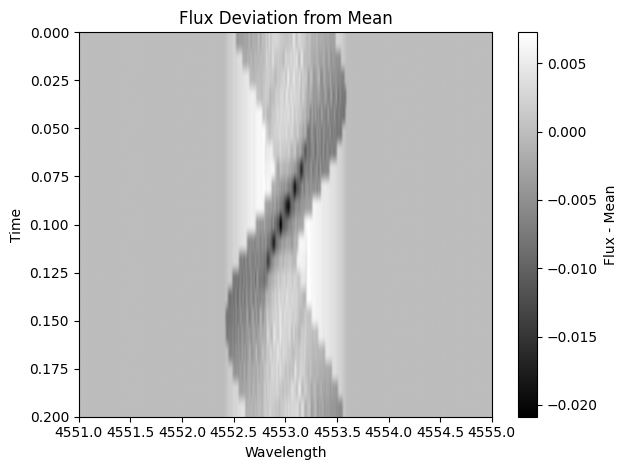

In [ ]:
plot_pl.plot_grayscale(wavelength_df=wavelength_gauss_df)

### Animation

In [24]:
#import numpy as np
#from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# plt.rcParams["animation.html"] = "jshtml"
plt.ioff() # To avoid showing the plot two times, you can do plt.ion() afterwards
fig = plt.figure()
ax = plt.axes(xlim=(4551.0, 4555.0), ylim=(0.95, 1.0))
line, = ax.plot([], [], lw=3)
time = plot_pl.extract_time_points_from_data(wavelength_df=wavelength_gauss_df)
wavelength = plot_pl.extract_wavelengths(wavelength_gauss_df,time=time[0])
def init():
    line.set_data([], [])
    return line,
def animate(i):
    j = i % time.len()
    #print(j)
    #x = wavelength
    #y = plot_pl.extract_flux(wavelength_df=wavelength_df,time=time[j])
    #x, y = wavelength_df.filter(pl.col('time').is_between(j*0.01, (j+1)*0.01)).select(['wavelength', 'normalized flux']).to_numpy().T
    x, y = wavelength_gauss_df.filter(pl.col('time').eq(j*0.01)).select(['wavelength', 'normalized flux']).to_numpy().T
    line.set_data(x, y)
    return line,

anim = FuncAnimation(fig, animate, init_func=init, frames=100, interval=4, blit=True); # May take some time
HTML(anim.to_jshtml())